<a href="https://colab.research.google.com/github/hsunh18/aq-ml-pipeline/blob/main/aq_preprocessing_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openaq
!pip install anthropic
!pip install shap
import os
from google.colab import userdata
import numpy as np
import pandas as pd
import json
import time
import openaq
import xgboost as xgb
from xgboost import plot_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import statsmodels.api as sm
import anthropic
sns.set_theme(style="dark")

api_key = userdata.get('OpenAQ_api')
api = openaq.OpenAQ(api_key=api_key)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.9/923.9 kB 14.9 MB/s eta 0:00:00


In [2]:
countries = api.countries.list(limit=200).results
for c in countries:
    print(c.id, c.name)

1 Indonesia
2 Malaysia
3 Chile
5 Peru
6 Argentina
7 Dhekelia
8 Cyprus
9 India
10 China
11 Israel
12 Palestine
13 Lebanon
14 Ethiopia
15 South Sudan
17 Kenya
18 Malawi
22 France
24 Guyana
25 Republic of Korea
27 Morocco
29 Costa Rica
30 Nicaragua
32 Democratic Republic of the Congo
33 Bhutan
34 Ukraine
37 South Africa
38 Saint-Martin
40 Oman
41 Uzbekistan
42 Kazakhstan
43 Tajikistan
44 Lithuania
45 Brazil
46 Uruguay
47 Mongolia
48 Russian Federation
49 Czech Republic
50 Germany
51 Estonia
52 Latvia
53 Norway
54 Sweden
55 Finland
56 Vietnam
57 Cambodia
58 Luxembourg
59 United Arab Emirates
60 Belgium
61 Georgia
62 North Macedonia
63 Albania
64 Azerbaijan
65 Kosovo
66 Turkey
67 Spain
68 Lao PDR
69 Kyrgyzstan
70 Armenia
71 Denmark
73 Tunisia
74 Romania
75 Hungary
76 Slovakia
77 Poland
78 Ireland
79 United Kingdom
80 Greece
81 Zambia
82 Sierra Leone
83 Guinea
84 Liberia
86 Sudan
89 Austria
90 Iraq
91 Italy
92 Switzerland
94 Netherlands
96 Côte d'Ivoire
97 Serbia
98 Mali
99 Senegal
100 Niger

In [3]:
locations_response = api.locations.list(
    countries_id=155,     # u.s id
    parameters_id=2,      # sensors
    limit=15              # first 15
)
for location in locations_response.results:
    print(f"Station ID: {location.id} | Name: {location.name} | Sensors: {[s.parameter.name for s in location.sensors]}")

Station ID: 162 | Name: Houston Deer Park C3 | Sensors: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']
Station ID: 164 | Name: Houston North Loop C | Sensors: ['co', 'no2', 'pm25']
Station ID: 173 | Name: Houston Westhollow C | Sensors: ['o3', 'pm25']
Station ID: 186 | Name: Houston Aldine C8 | Sensors: ['no2', 'o3', 'pm25']
Station ID: 187 | Name: Houston Bayland Park | Sensors: ['no2', 'o3', 'pm25']
Station ID: 191 | Name: Seabrook Friendship | Sensors: ['o3', 'pm25']
Station ID: 195 | Name: Houston Park Place C | Sensors: ['no2', 'o3', 'pm25', 'so2']
Station ID: 207 | Name: MMFRA1001 | Sensors: ['pm25']
Station ID: 209 | Name: Tooele | Sensors: ['pm25']
Station ID: 211 | Name: Felton Cal-Fire | Sensors: ['pm25']
Station ID: 212 | Name: ROLAND | Sensors: ['no', 'no2', 'nox', 'o3', 'pm10', 'pm25']
Station ID: 213 | Name: Twin Falls PM25 | Sensors: ['pm25']
Station ID: 214 | Name: MMFRA1001 | Sensors: ['pm25']
Station ID: 216 | Name: South Bend-Shields D | Sensors: ['no2', 'o3', 'pm25']
St


--- Philadelphia ---
Station: Clarksboro | Sensor ID: 7631565
                     time  value
0    2024-04-01T04:00:00Z    6.6
1    2024-04-01T05:00:00Z   11.3
2    2024-04-01T06:00:00Z   11.4
3    2024-04-01T07:00:00Z    7.4
4    2024-04-01T08:00:00Z    9.1
..                    ...    ...
295  2024-04-13T14:00:00Z    2.0
296  2024-04-13T15:00:00Z    3.8
297  2024-04-13T16:00:00Z    0.5
298  2024-04-13T17:00:00Z    3.9
299  2024-04-13T18:00:00Z    1.6

[300 rows x 2 columns]


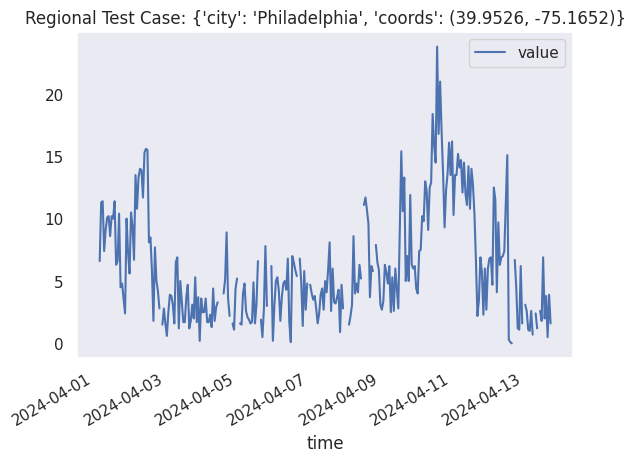


--- Taipei ---
Station: 臺北市 - 萬華 | Sensor ID: 7930492
                     time  value
0    2024-03-31T16:00:00Z   14.0
1    2024-03-31T17:00:00Z   16.0
2    2024-03-31T18:00:00Z   12.0
3    2024-03-31T19:00:00Z   15.0
4    2024-03-31T20:00:00Z   17.0
..                    ...    ...
295  2024-04-13T22:00:00Z   18.0
296  2024-04-13T23:00:00Z   23.0
297  2024-04-14T00:00:00Z   36.0
298  2024-04-14T01:00:00Z   34.0
299  2024-04-14T02:00:00Z   38.0

[300 rows x 2 columns]


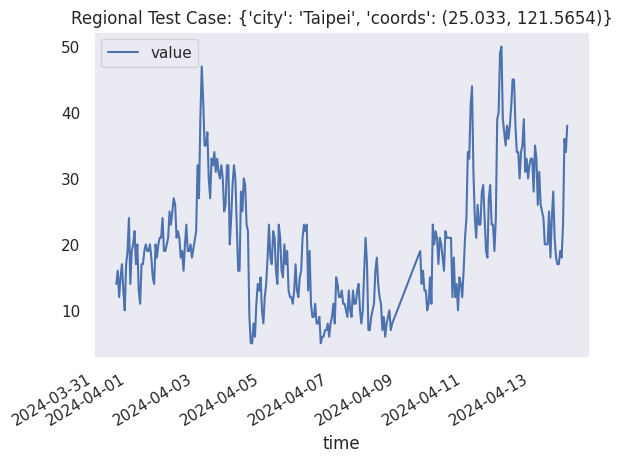


--- Vancouver ---
Station: Kensington Park | Sensor ID: 2156
                     time  value
0    2024-04-01T08:00:00Z    2.0
1    2024-04-01T09:00:00Z    1.9
2    2024-04-01T10:00:00Z    2.4
3    2024-04-01T11:00:00Z    2.9
4    2024-04-01T12:00:00Z    3.1
..                    ...    ...
295  2024-04-13T18:00:00Z    9.9
296  2024-04-13T19:00:00Z   15.4
297  2024-04-13T20:00:00Z   10.1
298  2024-04-13T21:00:00Z    8.2
299  2024-04-13T22:00:00Z    5.4

[300 rows x 2 columns]


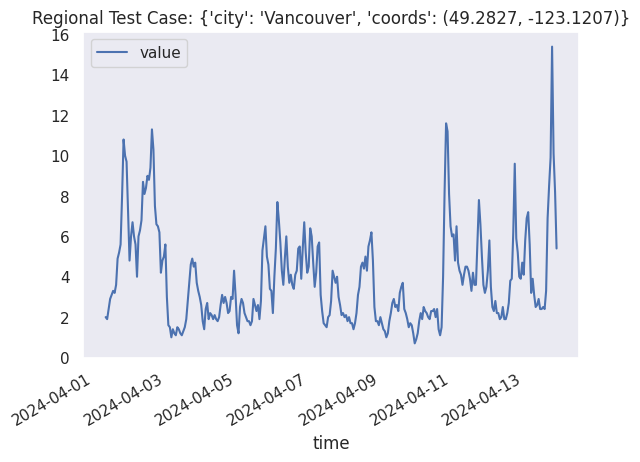

In [4]:
test_cases = [
    {"city": "Philadelphia", "coords": (39.9526, -75.1652)},
    {"city": "Taipei",  "coords": (25.0330, 121.5654)},
    {"city": "Vancouver",      "coords": (49.2827, -123.1207)}
]

city_dfs = {}

for case in test_cases:
    print(f"\n--- {case['city']} ---")

    # pass to tuples
    locs = api.locations.list(
        coordinates=case["coords"],
        radius=25000,
        parameters_id=2,
        limit=5
    ).results

    if not locs:
        print("No active PM2.5 stations found in this radius.")
        city_dfs[case['city']] = pd.DataFrame() # store an empty df
        continue

    station = locs[0]
    pm25_sensor = next(s for s in station.sensors if s.parameter.name == "pm25")
    print(f"Station: {station.name} | Sensor ID: {pm25_sensor.id}")


    meas = api.measurements.list(
        sensors_id=pm25_sensor.id,
        datetime_from="2024-04-01",
        datetime_to="2024-05-01",
        limit=300  # reduced limit to prevent timeouts
    ).results

    df = pd.DataFrame([{
    "time": m.period.datetime_from.utc,
    "value": m.value,
} for m in meas])
    city_dfs[case['city']] = df

    print(df)
    df["time"] = pd.to_datetime(df["time"])
    df.plot(x="time", y="value", kind="line",title=f"Regional Test Case: {case}")
    plt.show()

Philadelphia — MAE: 3.70  RMSE: 5.26 µg/m³
Taipei — MAE: 6.58  RMSE: 8.13 µg/m³
Vancouver — MAE: 1.11  RMSE: 1.60 µg/m³


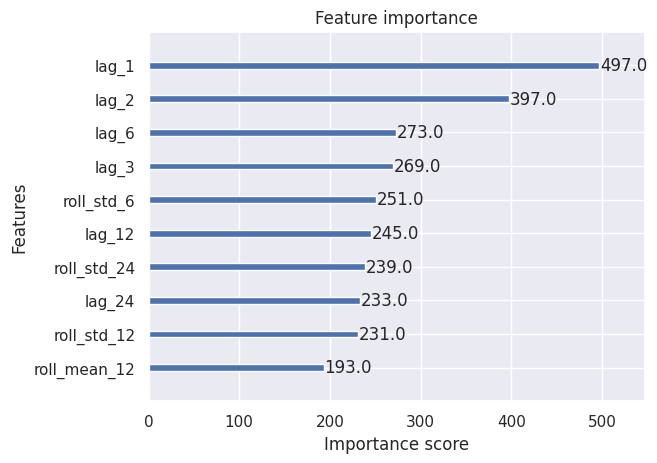

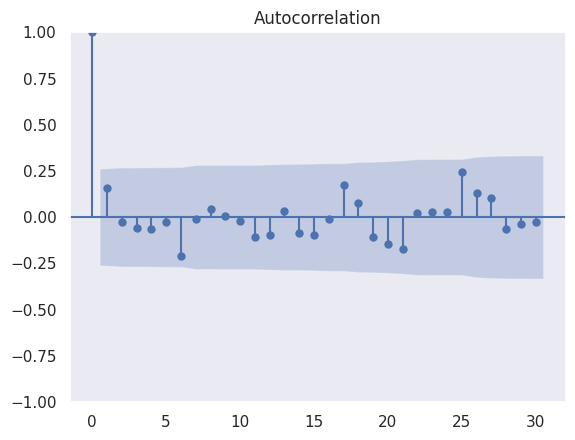

In [5]:
lags = [1, 2, 3, 6, 12, 24] # time steps
rolls = [6, 12, 24] # trends on specific hours
params = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1) # 80% of rows
# build features
feature_cols = ([f"lag_{l}" for l in lags] +
                [f"roll_mean_{w}" for w in rolls] +
                [f"roll_std_{w}"  for w in rolls] +
                ["hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos", "month"])

models = {} # for each city
for city, raw in city_dfs.items():
    if raw.empty: #skip empty dfs
        continue

    df = raw.copy()
    df["time"] = pd.to_datetime(df["time"]) # convert the literal string

    for lag in lags:
        df[f"lag_{lag}"] = df["value"].shift(lag)
    for w in rolls:
        df[f"roll_mean_{w}"] = df["value"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["value"].shift(1).rolling(w).std()
    for col, period in [("hour", 24), ("dayofweek", 7)]:
        df[col] = getattr(df["time"].dt, col)
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period) # wrap around
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)
    df["month"] = df["time"].dt.month
    df.dropna(inplace=True)

    split = int(len(df) * 0.8) # split train and test 80/20
    X_train, X_test = df[feature_cols][:split], df[feature_cols][split:]
    y_train, y_test = df["value"][:split], df["value"][split:]

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    models[city] = model

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    print(f"{city} — MAE: {mae:.2f}  RMSE: {rmse:.2f} µg/m³")

plot_importance(model, max_num_features=10)
plt.show()

# autocorrelation/gaussian white noise
residuals = y_test - preds
sm.graphics.tsa.plot_acf(residuals, lags=30)
plt.show()

Begin prepocessing and area selection


In [6]:
continent_countries = {
    "Africa":        [100],
    "South_Asia":    [9],
    "Europe":        [79],
    "South_America": [45],
    "North_America": [155, 156],
    "East_Asia":     [189],
}

city_dfs = {}

for continent, country_ids in continent_countries.items():
    print({continent})

    for country_id in country_ids: # find 10 monitoring locations in each country
        locs = api.locations.list(
            countries_id=country_id,
            parameters_id=2,
            limit=8
        ).results

        if not locs:
            print("No sensor found")
            continue

        for station in locs: # check if a sensor at station measures pm25
            pm25_sensor = next((s for s in station.sensors if s.parameter.name == "pm25"), None)

            if not pm25_sensor:
                continue

            print(f"Station: {station.name}, ID: {station.id}")

            meas = api.measurements.list( #300 measurements
                sensors_id=pm25_sensor.id,
                datetime_from="2024-04-01",
                datetime_to="2024-05-01",
                limit=300
            ).results

            if not meas:
                continue

            raw = [{
                "time": m.period.datetime_from.utc,
                "value": m.value
            } for m in meas]

            df = pd.DataFrame(raw)
            if df['value'].max() == 0:
              continue
            key = f"{continent}_{station.name}"
            city_dfs[key] = df
            print(df.head())
            time.sleep(3) # avoid rate limits

{'Africa'}
Station: SPARTAN - Ilorin University, ID: 42
Station: Abuja, ID: 220715
                   time  value
0  2024-03-31T23:00:00Z    3.7
1  2024-04-01T00:00:00Z    2.6
2  2024-04-01T01:00:00Z    2.3
3  2024-04-01T02:00:00Z    6.5
4  2024-04-01T03:00:00Z    6.0
Station: Lagos, ID: 404479
Station: SPARTAN - Ilorin University, ID: 1285346
Station: Ogada, Obubra Local Government Area (LGA), ID: 1894636
Station: Calabar, ID: 1894640
                   time  value
0  2024-03-31T23:02:42Z  11.51
1  2024-03-31T23:20:07Z   7.59
2  2024-03-31T23:37:32Z   5.47
3  2024-03-31T23:54:57Z   6.32
4  2024-04-01T00:12:22Z   6.93
Station: University of Lagos/Makoko, ID: 3400895
Station: Sagamu Road - Ikorodu, ID: 4579812
{'South_Asia'}
Station: SPARTAN - IIT Kanpur, ID: 12
Station: Delhi Technological University, Delhi - CPCB, ID: 13
Station: IGI Airport, ID: 15
Station: Civil Lines, ID: 16
Station: R K Puram, Delhi - DPCC, ID: 17
Station: Punjabi Bagh, Delhi - DPCC, ID: 50
Station: Income Tax Off

In [7]:
# LLM preprocess
# ── 1. PARSE & INDEX ──────────────────────────────────────────────────────────
def parse_and_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)   # force UTC-aware
    df = df.sort_values("time").drop_duplicates("time")  # sort + dedup
    df = df.set_index("time")
    return df

# ── 2. RESAMPLE & INTERPOLATE ─────────────────────────────────────────────────
def resample_and_fill(df: pd.DataFrame, freq: str = "1h", max_gap_h: int = 3) -> pd.DataFrame:
    """
    Snap to a regular hourly grid.
    Gaps <= max_gap_h hours are filled with linear interpolation.
    Larger gaps remain NaN (will be dropped later by dropna in feature step).
    """
    df = df.resample(freq).mean()                        # aggregate if sub-hourly dupes
    df["value"] = df["value"].interpolate(
        method="time",
        limit=max_gap_h,
        limit_direction="forward"
    )
    return df

# ── 3. OUTLIER REMOVAL ────────────────────────────────────────────────────────
def remove_outliers(df: pd.DataFrame, k: float = 3.0) -> pd.DataFrame:
    """
    IQR fence: anything outside [Q1 - k*IQR, Q3 + k*IQR] is clipped.
    k=3 is lenient (good for PM2.5 which can spike legitimately during events).
    Also zero-floors negatives — sensors sometimes report -0.x.
    """
    df = df.copy()
    q1, q3 = df["value"].quantile(0.25), df["value"].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    df["value"] = df["value"].clip(lower=max(lo, 0.0), upper=hi)
    return df

# ── 4. FEATURE ENGINEERING ────────────────────────────────────────────────────
lags  = [1, 2, 3, 6, 12, 24]
rolls = [6, 12, 24]

def engineer_features(df: pd.DataFrame, continent: str, station: str) -> pd.DataFrame:
    df = df.copy()

    # Lag features
    for l in lags:
        df[f"lag_{l}"] = df["value"].shift(l)

    # Rolling mean and std (shift(1) to avoid leakage)
    for w in rolls:
        df[f"roll_mean_{w}"] = df["value"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["value"].shift(1).rolling(w).std()

    # Cyclical time encodings
    df["hour"]      = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"]     = df.index.month

    for col, period in [("hour", 24), ("dayofweek", 7)]:
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

    # Identity columns for OHE (added as strings, encoded later)
    df["continent"] = continent
    df["station"]   = station

    df.dropna(inplace=True)
    return df

# ── 5 & 6. NORMALIZE + OHE ───────────────────────────────────────────────────
# Columns that get StandardScaler
scale_cols = (
    ["value"]
    + [f"lag_{l}"        for l in lags]
    + [f"roll_mean_{w}"  for w in rolls]
    + [f"roll_std_{w}"   for w in rolls]
)
# Cyclical + month stay as-is (already bounded); OHE targets
ohe_cols   = ["continent", "station"]
passthrough = ["hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos", "month"]

# ── MAIN PIPELINE ─────────────────────────────────────────────────────────────
processed_dfs = {}

for key, raw in city_dfs.items():
    if raw.empty:
        continue

    # REPLACE with this
    if   key.startswith("North_America"): continent, station = "North_America", key[len("North_America_"):]
    elif key.startswith("East_Asia"):     continent, station = "East_Asia",     key[len("East_Asia_"):]
    elif key.startswith("South_Asia"):    continent, station = "South_Asia",    key[len("South_Asia_"):]
    elif key.startswith("South_America"): continent, station = "South_America", key[len("South_America_"):]
    else:
      parts = key.split("_", 1)
      continent, station = parts[0], parts[1]

    df = parse_and_index(raw)
    df = resample_and_fill(df)
    df = remove_outliers(df)
    df = engineer_features(df, continent, station)

    processed_dfs[key] = df
    print(f"{key:45s}  rows: {len(df):>4d}  PM2.5 range: [{df['value'].min():.1f}, {df['value'].max():.1f}]")

# ── Build combined frame + fit transformers ───────────────────────────────────
combined = pd.concat(processed_dfs.values(), axis=0)
print(f"\nCombined shape before encoding: {combined.shape}")

feature_cols = scale_cols + passthrough + ohe_cols

ct = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(),               scale_cols),
        ("pass",   "passthrough",                  passthrough),
        ("ohe",    OneHotEncoder(sparse_output=False,
                                 handle_unknown="ignore"), ohe_cols),
    ],
    remainder="drop"
)

X = combined[feature_cols].copy()
y = combined["value"].values

X_transformed = ct.fit_transform(X)

# Recover readable column names
ohe_feature_names = ct.named_transformers_["ohe"].get_feature_names_out(ohe_cols).tolist()
final_cols = scale_cols + passthrough + ohe_feature_names

df_final = pd.DataFrame(X_transformed, columns=final_cols, index=combined.index)
df_final["target"] = y  # raw (unscaled) target — XGBoost doesn't need scaled y

print(f"Final shape after encoding:     {df_final.shape}")
print(f"\nOHE columns added: {ohe_feature_names}")
print(f"\nSample:\n{df_final.head(3).to_string()}")

Africa_Abuja                                   rows:  278  PM2.5 range: [1.2, 63.4]
Africa_Calabar                                 rows:   81  PM2.5 range: [6.6, 61.5]
Europe_London Harlington - UKA00472            rows:  293  PM2.5 range: [2.0, 6.0]
Europe_Southwark - A2 Old Kent Road            rows:  276  PM2.5 range: [0.7, 15.7]
Europe_London Bloomsbury - UKA00211            rows:  306  PM2.5 range: [3.0, 6.0]
North_America_Houston North Loop C             rows:  279  PM2.5 range: [0.0, 30.5]
North_America_Houston Westhollow C             rows:  285  PM2.5 range: [0.1, 41.6]
North_America_Houston Aldine C8                rows:  278  PM2.5 range: [0.0, 31.0]
North_America_Houston Bayland Park             rows:  278  PM2.5 range: [0.6, 25.5]
North_America_Seabrook Friendship              rows:  258  PM2.5 range: [0.3, 20.9]
North_America_St. Lina                         rows:  281  PM2.5 range: [0.4, 7.9]
North_America_Steeper                          rows:  277  PM2.5 range: [0.0, 4

In [8]:
results = {}
params = dict(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

for key, df in processed_dfs.items():
    if df.empty:
        continue
    split = int(len(df) * 0.8)
    train = df.iloc[:split]
    test  = df.iloc[split:]
    drop_cols = ["continent", "station", "hour", "dayofweek"]
    feat_cols = [c for c in df.columns if c not in drop_cols and c != "target"]
    X_train, y_train = train[feat_cols], train["value"]
    X_test,  y_test  = test[feat_cols],  test["value"]
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    results[key] = {"MAE": round(mae, 2), "RMSE": round(rmse, 2)}
    print(f"{key:45s}  MAE: {mae:.2f}  RMSE: {rmse:.2f} µg/m³")


Africa_Abuja                                   MAE: 1.23  RMSE: 2.69 µg/m³
Africa_Calabar                                 MAE: 1.09  RMSE: 1.59 µg/m³
Europe_London Harlington - UKA00472            MAE: 0.29  RMSE: 0.52 µg/m³
Europe_Southwark - A2 Old Kent Road            MAE: 0.13  RMSE: 0.17 µg/m³
Europe_London Bloomsbury - UKA00211            MAE: 0.05  RMSE: 0.08 µg/m³
North_America_Houston North Loop C             MAE: 0.35  RMSE: 0.42 µg/m³
North_America_Houston Westhollow C             MAE: 0.33  RMSE: 0.52 µg/m³
North_America_Houston Aldine C8                MAE: 0.32  RMSE: 0.52 µg/m³
North_America_Houston Bayland Park             MAE: 0.24  RMSE: 0.33 µg/m³
North_America_Seabrook Friendship              MAE: 0.18  RMSE: 0.27 µg/m³
North_America_St. Lina                         MAE: 0.13  RMSE: 0.19 µg/m³
North_America_Steeper                          MAE: 0.05  RMSE: 0.07 µg/m³
North_America_Bruderheim                       MAE: 0.19  RMSE: 0.37 µg/m³
North_America_Patricia Mc

In [9]:
# see all available keys
for k in city_dfs.keys():
    print(k)

Africa_Abuja
Africa_Calabar
Europe_London Harlington - UKA00472
Europe_Southwark - A2 Old Kent Road
Europe_London Bloomsbury - UKA00211
North_America_Houston North Loop C
North_America_Houston Westhollow C
North_America_Houston Aldine C8
North_America_Houston Bayland Park
North_America_Seabrook Friendship
North_America_St. Lina
North_America_Steeper
North_America_Bruderheim
North_America_Patricia McInnes
North_America_Elk Island
North_America_RED DEER RIVERSIDE D
North_America_Edson
East_Asia_屏東縣 - 恆春
East_Asia_臺北市 - 萬華
East_Asia_臺東縣 - 臺東
East_Asia_南投縣 - 竹山
East_Asia_屏東縣 - 屏東


            value
count  300.000000
mean     4.340000
std      1.164296
min      3.000000
25%      3.000000
50%      4.000000
75%      5.000000
max      6.000000
0
300


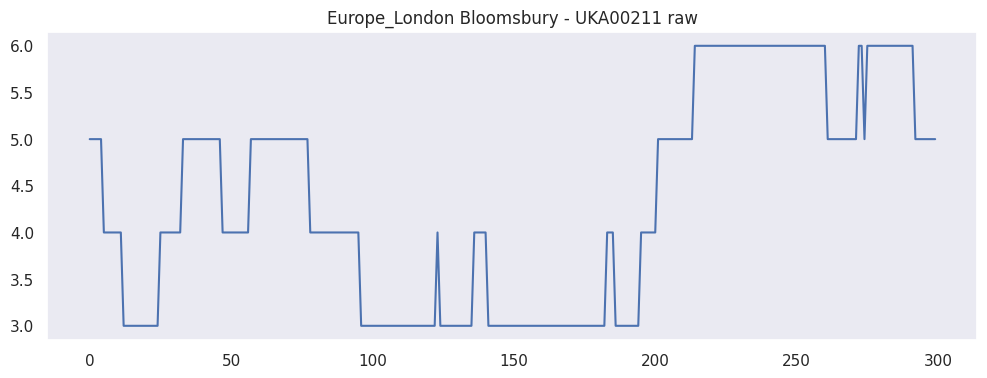

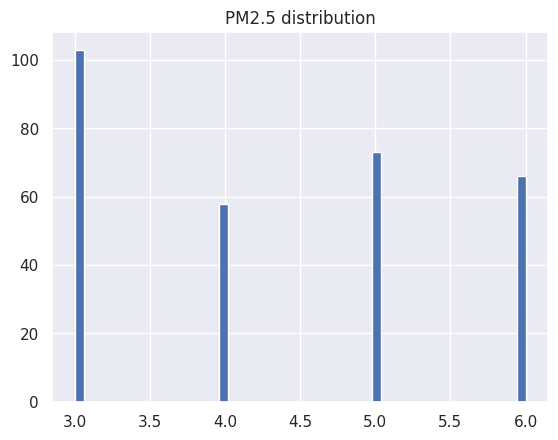

In [10]:
# manual cleaning
key = "Europe_London Bloomsbury - UKA00211"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df.sort_values("time").set_index("time")

print(df.describe())
print(df['value'].isnull().sum())
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key} raw")
plt.show()

# distribution
df["value"].hist(bins=50)
plt.title("PM2.5 distribution")
plt.show()



In [11]:
df = df.set_index("time").sort_index()
df_resampled = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled)}")
print(f"New missing values after resample: {df_resampled['value'].isnull().sum()}")

df_resampled["value"] = df_resampled["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)
print(f"Missing after interpolation: {df_resampled['value'].isnull().sum()}")
manual_cleaned = {} #save it into a dict
manual_cleaned["Europe_London Bloomsbury - UKA00211"] = df_resampled

Rows before resample: 300
Rows after resample: 330
New missing values after resample: 30
Missing after interpolation: 0


            value
count  300.000000
mean    20.306667
std     13.008676
min      1.200000
25%      5.700000
50%     21.350000
75%     28.775000
max     63.400000
0
300


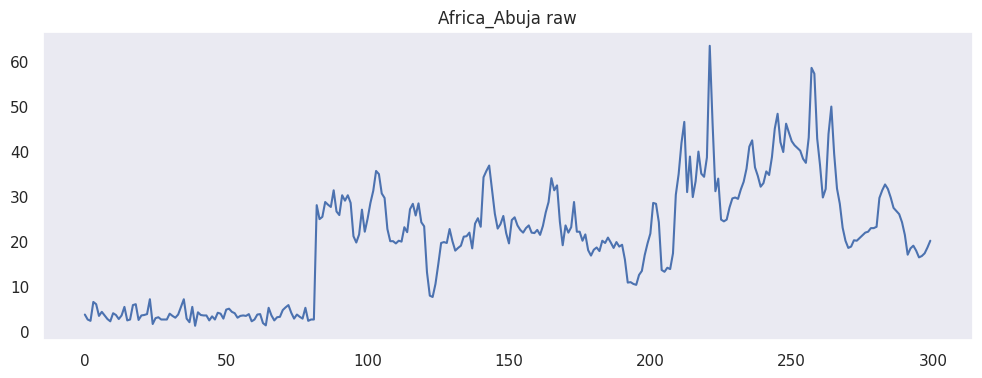

'print(df.describe())\nprint(f"\nValues above 60: {(df[\'value\'] > 60).sum()}")\nprint(f"Missing values: {df[\'value\'].isnull().sum()}")\nprint(f"Negatives: {(df[\'value\'] < 0).sum()}")\n'

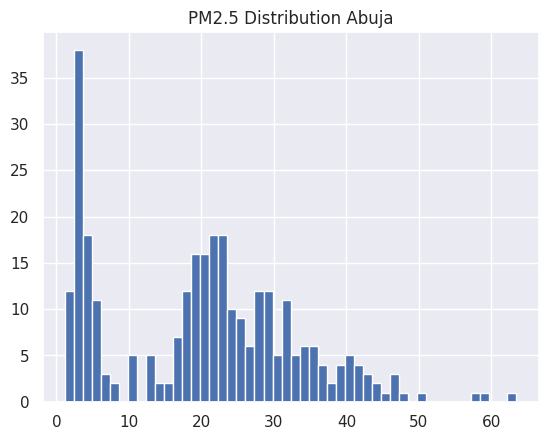

In [12]:
key = "Africa_Abuja"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df.sort_values("time").set_index("time")

print(df.describe())
print(df['value'].isnull().sum())
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key} raw")
plt.show()
df["value"].hist(bins=50)
plt.title("PM2.5 Distribution Abuja")
plt.show

df.iloc[200:230] # finding spike
'''print(df.describe())
print(f"\nValues above 60: {(df['value'] > 60).sum()}")
print(f"Missing values: {df['value'].isnull().sum()}")
print(f"Negatives: {(df['value'] < 0).sum()}")
'''

In [13]:
df = df.set_index("time").sort_index()
df_resampled_abuja = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled_abuja)}")
print(f"Missing after resample: {df_resampled_abuja['value'].isnull().sum()}")

df_resampled_abuja["value"] = df_resampled_abuja["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)

print(f"Missing values after interpolate {df_resampled_abuja["value"].isnull().sum()}")
manual_cleaned["Africa_Abuja"] = df_resampled_abuja

Rows before resample: 300
Rows after resample: 302
Missing after resample: 2
Missing values after interpolate 0


            value
count  296.000000
mean     9.226351
std      5.892412
min      0.000000
25%      5.000000
50%      8.000000
75%     13.000000
max     31.000000
Null vals: 4
300


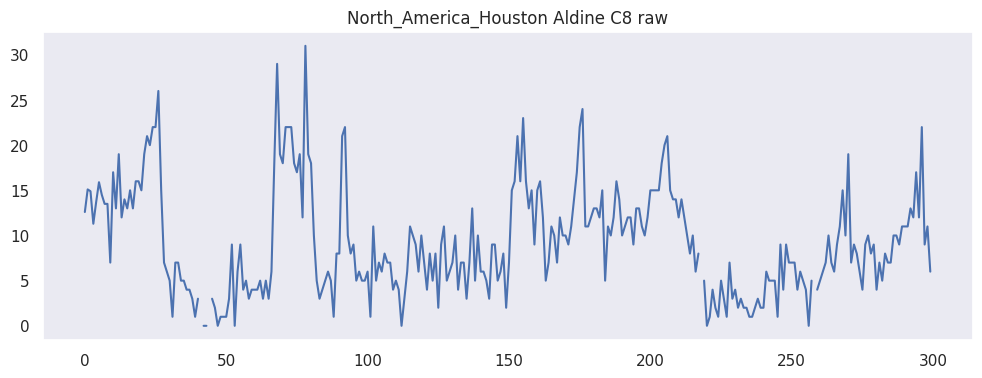

<function matplotlib.pyplot.show(close=None, block=None)>

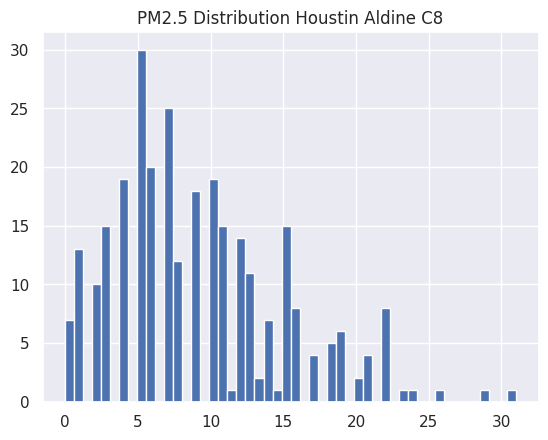

In [14]:
key = "North_America_Houston Aldine C8"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df.sort_values("time").set_index("time")

print(df.describe())
print(f"Null vals: {df['value'].isnull().sum()}")
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key} raw")
plt.show()

df["value"].hist(bins=50)
plt.title("PM2.5 Distribution Houstin Aldine C8")
plt.show

In [15]:
print(f"Min value: {df['value'].min()}")
print(f"Values below 0.5: {(df['value'] < 0.5).sum()}")
print(df[df['value'] < 0.5])
df["value"] = df["value"].replace(0.0, float("nan"))
print(f"NaN values after zero replacement: {df['value'].isnull().sum()}")

Min value: 0.0
Values below 0.5: 7
                         time  value
42  2024-04-03 01:00:00+00:00    0.0
43  2024-04-03 02:00:00+00:00    0.0
47  2024-04-03 06:00:00+00:00    0.0
53  2024-04-03 12:00:00+00:00    0.0
112 2024-04-05 23:00:00+00:00    0.0
220 2024-04-10 11:00:00+00:00    0.0
256 2024-04-11 23:00:00+00:00    0.0
NaN values after zero replacement: 11


In [16]:
df = df.set_index("time").sort_index()
df_resampled_hous = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled_hous)}")
print(f"Missing after resample: {df_resampled_hous['value'].isnull().sum()}")

df_resampled_hous["value"] = df_resampled_hous["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)
print(f"Missing after interpolation {df_resampled_hous["value"].isnull().sum()}")

manual_cleaned["North_America_Houston Aldine C8"] = df_resampled_hous

Rows before resample: 300
Rows after resample: 302
Missing after resample: 13
Missing after interpolation 1


            value
count  300.000000
mean    10.803333
std      7.144331
min      1.000000
25%      6.000000
50%      9.000000
75%     13.000000
max     36.000000
Null vals 0
300


,value
time,
2024-04-03 04:00:00+00:00,36.0
2024-04-03 05:00:00+00:00,31.0
2024-04-03 06:00:00+00:00,33.0
2024-04-03 08:00:00+00:00,26.0
2024-04-03 09:00:00+00:00,29.0
2024-04-03 10:00:00+00:00,27.0
2024-04-03 11:00:00+00:00,30.0
2024-04-03 12:00:00+00:00,24.0
2024-04-03 13:00:00+00:00,25.0


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 23631 (\N{CJK UNIFIED IDEOGRAPH-5C4F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 26481 (\N{CJK UNIFIED IDEOGRAPH-6771}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 32291 (\N{CJK UNIFIED IDEOGRAPH-7E23}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 24646 (\N{CJK UNIFIED IDEOGRAPH-6046}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 26149 (\N{CJK UNIFIED IDEOGRAPH-6625}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: 

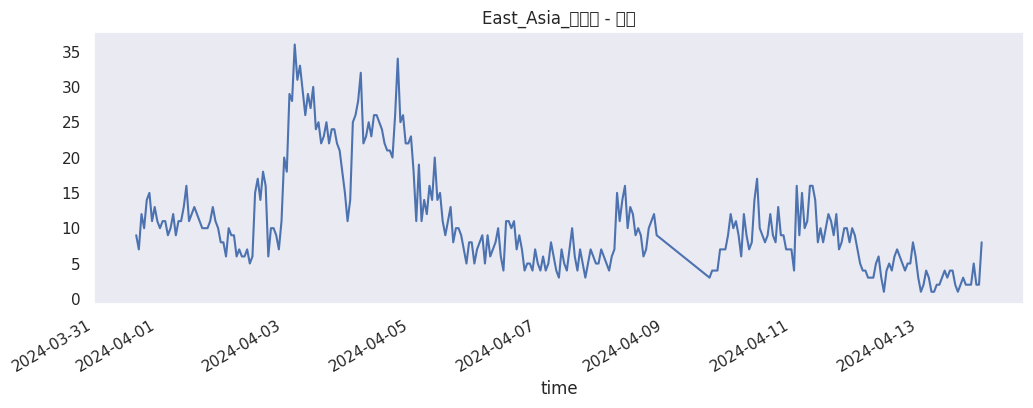

In [17]:
key = "East_Asia_屏東縣 - 恆春"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.set_index("time").sort_index()

print(df.describe())
print(f"Null vals {df['value'].isnull().sum()}")
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key}")
plt.show

df.iloc[60:90]

In [18]:
df_resampled_heng = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled_heng)}")
print(f"Missing after resample: {df_resampled_heng['value'].isnull().sum()}")

df_resampled_heng["value"] = df_resampled_heng["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)
print(f"Missing after interpolation {df_resampled_heng['value'].isnull().sum()}")
manual_cleaned["East_Asia_屏東縣 - 恆春"] = df_resampled_heng

Rows before resample: 300
Rows after resample: 321
Missing after resample: 21
Missing after interpolation 16


            value
count  300.000000
mean     3.837667
std      3.070740
min      0.600000
25%      1.600000
50%      2.700000
75%      5.400000
max     15.000000
Missing values: 0
300


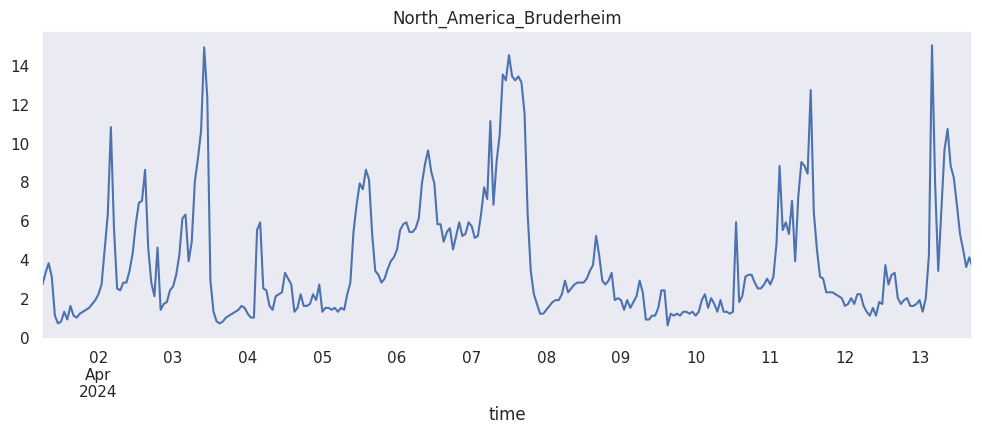

In [19]:
key = "North_America_Bruderheim"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.sort_values("time").set_index("time")

print(df.describe())
print(f"Missing values: {df['value'].isnull().sum()}")
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key}")
plt.show()

In [20]:
df_resampled_brun = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resampled_brun)}")

df_resampled_brun["value"] = df_resampled_brun["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)

print(f"Missing after interpolation {df_resampled_brun['value'].isnull().sum()}")
manual_cleaned["North_America_Bruderheim"] = df_resampled_brun

Rows before resample: 300
Rows after resample: 300
Missing after interpolation 0


            value
count  300.000000
mean    20.340000
std      9.429428
min      5.000000
25%     13.000000
50%     19.000000
75%     25.250000
max     50.000000
Null vals 0
300


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33274 (\N{CJK UNIFIED IDEOGRAPH-81FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33836 (\N{CJK UNIFIED IDEOGRAPH-842C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33775 (\N{CJK UNIFIED IDEOGRAPH-83EF}) missing from font(s) DejaVu Sans.
  fig.canvas

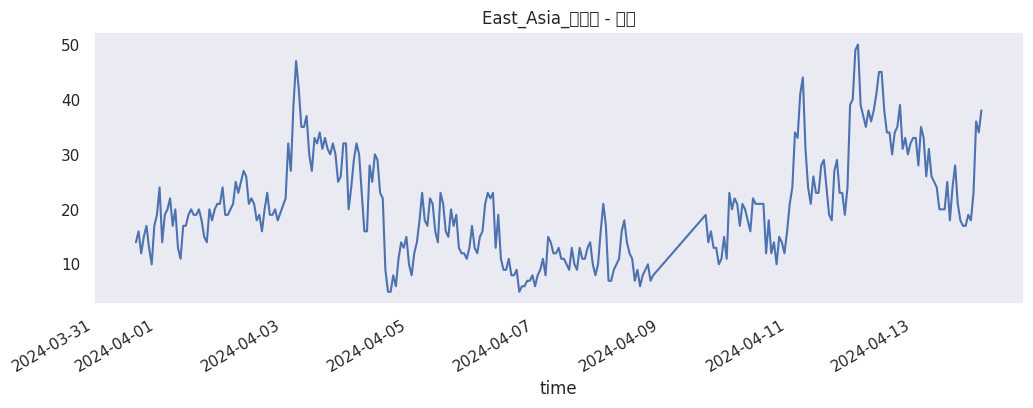

In [21]:
key = "East_Asia_臺北市 - 萬華"
df = city_dfs[key].copy()
df["time"] = pd.to_datetime(df["time"], utc=True)
df = df.sort_values("time").set_index("time")

print(df.describe())
print(f"Null vals {df['value'].isnull().sum()}")
print(len(df))

df["value"].plot(figsize=(12,4), title=f"{key}")
plt.show()

In [22]:
df_resample_tai = df.resample("1h").mean()
print(f"Rows before resample: {len(df)}")
print(f"Rows after resample: {len(df_resample_tai)}")
print(f"Missing after resample: {df_resample_tai['value'].isnull().sum()}")

df_resample_tai["value"] = df_resample_tai["value"].interpolate(
    method="time",
    limit=3,
    limit_direction="forward"
)
print(f"Missing after interpolation {df_resample_tai['value'].isnull().sum()}")
manual_cleaned["East_Asia_臺北市 - 萬華"] = df_resample_tai

Rows before resample: 300
Rows after resample: 323
Missing after resample: 23
Missing after interpolation 16


In [23]:
# ── STRICT FEATURE ENGINEERING ONLY ──────────────────────────────────────────
def strict_feature_engineering(df: pd.DataFrame, continent: str, station: str) -> pd.DataFrame:
    """
    Takes already-cleaned data and strictly applies mathematical transformations.
    Does NOT drop, clip, or interpolate the target 'value' column.
    """
    df = df.copy()

    # 1. Lag features
    for l in lags:
        df[f"lag_{l}"] = df["value"].shift(l)

    # 2. Rolling mean and std (shift(1) to avoid data leakage)
    for w in rolls:
        df[f"roll_mean_{w}"] = df["value"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["value"].shift(1).rolling(w).std()

    # 3. Cyclical time encodings
    df["hour"]      = df.index.hour
    df["dayofweek"] = df.index.dayofweek
    df["month"]     = df.index.month

    for col, period in [("hour", 24), ("dayofweek", 7)]:
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

    # 4. Identity columns for One-Hot Encoding
    df["continent"] = continent
    df["station"]   = station

    # Drop rows that don't have enough history for lags/rolling stats
    df.dropna(inplace=True)
    return df

In [24]:
# engineer features on manually cleaned stations
manual_processed = {}

for key, df in manual_cleaned.items():
    if key.startswith("North_America"): continent, station = "North_America", key[len("North_America_"):]
    elif key.startswith("East_Asia"):    continent, station = "East_Asia",     key[len("East_Asia_"):]
    elif key.startswith("South_Asia"):   continent, station = "South_Asia",    key[len("South_Asia_"):]
    elif key.startswith("South_America"):continent, station = "South_America", key[len("South_America_"):]
    else:
        parts = key.split("_", 1)
        continent, station = parts[0], parts[1]

    df_feat = strict_feature_engineering(df, continent, station)
    manual_processed[key] = df_feat
    print(f"{key:45s}  rows: {len(df_feat)}")
print(manual_cleaned.keys())

Europe_London Bloomsbury - UKA00211            rows: 306
Africa_Abuja                                   rows: 278
North_America_Houston Aldine C8                rows: 253
East_Asia_屏東縣 - 恆春                             rows: 257
North_America_Bruderheim                       rows: 276
East_Asia_臺北市 - 萬華                             rows: 259
dict_keys(['Europe_London Bloomsbury - UKA00211', 'Africa_Abuja', 'North_America_Houston Aldine C8', 'East_Asia_屏東縣 - 恆春', 'North_America_Bruderheim', 'East_Asia_臺北市 - 萬華'])


In [25]:
# check what llm pipeline did with houston zeros around apri 3rd
key = "North_America_Houston Aldine C8"

# raw data
print("RAW DATA around April 3rd:")
raw = city_dfs[key].copy()
raw["time"] = pd.to_datetime(raw["time"], utc=True)
raw = raw.sort_values("time").set_index("time")
print(raw["2024-04-03 00:00:00+00:00":"2024-04-03 13:00:00+00:00"])

print("\nLLM PIPELINE output around April 3rd:")
print(processed_dfs[key]["value"]["2024-04-03 00:00:00+00:00":"2024-04-03 13:00:00+00:00"])

print("\nMANUAL PROCESSED output around April 3rd:")
print(manual_processed[key]["value"]["2024-04-03 00:00:00+00:00":"2024-04-03 13:00:00+00:00"])

RAW DATA around April 3rd:
                           value
time                            
2024-04-03 00:00:00+00:00    NaN
2024-04-03 01:00:00+00:00    0.0
2024-04-03 02:00:00+00:00    0.0
2024-04-03 03:00:00+00:00    NaN
2024-04-03 04:00:00+00:00    3.0
2024-04-03 05:00:00+00:00    2.0
2024-04-03 06:00:00+00:00    0.0
2024-04-03 07:00:00+00:00    1.0
2024-04-03 08:00:00+00:00    1.0
2024-04-03 09:00:00+00:00    1.0
2024-04-03 10:00:00+00:00    3.0
2024-04-03 11:00:00+00:00    9.0
2024-04-03 12:00:00+00:00    0.0
2024-04-03 13:00:00+00:00    6.0

LLM PIPELINE output around April 3rd:
time
2024-04-03 00:00:00+00:00    1.5
2024-04-03 01:00:00+00:00    0.0
2024-04-03 02:00:00+00:00    0.0
2024-04-03 03:00:00+00:00    1.5
2024-04-03 04:00:00+00:00    3.0
2024-04-03 05:00:00+00:00    2.0
2024-04-03 06:00:00+00:00    0.0
2024-04-03 07:00:00+00:00    1.0
2024-04-03 08:00:00+00:00    1.0
2024-04-03 09:00:00+00:00    1.0
2024-04-03 10:00:00+00:00    3.0
2024-04-03 11:00:00+00:00    9.0
2024-

In [26]:
key = "East_Asia_臺北市 - 萬華"
raw = city_dfs[key].copy()
raw["time"] = pd.to_datetime(raw["time"], utc=True)
raw = raw.sort_values("time").set_index("time")
print("RAW output:")
print(raw["value"])

print("\nLLM PIPELINE output:")
print(processed_dfs[key]["value"])

print("\nMANUAL PROCESSED output:")
print(manual_processed[key]["value"])

RAW output:
time
2024-03-31 16:00:00+00:00    14.0
2024-03-31 17:00:00+00:00    16.0
2024-03-31 18:00:00+00:00    12.0
2024-03-31 19:00:00+00:00    15.0
2024-03-31 20:00:00+00:00    17.0
                             ... 
2024-04-13 22:00:00+00:00    18.0
2024-04-13 23:00:00+00:00    23.0
2024-04-14 00:00:00+00:00    36.0
2024-04-14 01:00:00+00:00    34.0
2024-04-14 02:00:00+00:00    38.0
Name: value, Length: 300, dtype: float64

LLM PIPELINE output:
time
2024-04-01 16:00:00+00:00    20.0
2024-04-01 17:00:00+00:00    18.0
2024-04-01 18:00:00+00:00    15.0
2024-04-01 19:00:00+00:00    14.0
2024-04-01 20:00:00+00:00    20.0
                             ... 
2024-04-13 22:00:00+00:00    18.0
2024-04-13 23:00:00+00:00    23.0
2024-04-14 00:00:00+00:00    36.0
2024-04-14 01:00:00+00:00    34.0
2024-04-14 02:00:00+00:00    38.0
Name: value, Length: 259, dtype: float64

MANUAL PROCESSED output:
time
2024-04-01 16:00:00+00:00    20.0
2024-04-01 17:00:00+00:00    18.0
2024-04-01 18:00:00+00:00  

In [31]:
# statistical reasoning
# turkey fences
key = "East_Asia_臺北市 - 萬華"
df = city_dfs[key].copy()
q1 = df["value"].quantile(0.25)
q3 = df["value"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3.0 * iqr
upper_bound = q3 + 3.0 * iqr
lower_bound = max(lower_bound, 0.0)

df.loc[(df['value'] < lower_bound) | (df['value'] > upper_bound), 'value'] = float('nan')

print(df.describe())
print(df)

            value
count  300.000000
mean    20.340000
std      9.429428
min      5.000000
25%     13.000000
50%     19.000000
75%     25.250000
max     50.000000
                     time  value
0    2024-03-31T16:00:00Z   14.0
1    2024-03-31T17:00:00Z   16.0
2    2024-03-31T18:00:00Z   12.0
3    2024-03-31T19:00:00Z   15.0
4    2024-03-31T20:00:00Z   17.0
..                    ...    ...
295  2024-04-13T22:00:00Z   18.0
296  2024-04-13T23:00:00Z   23.0
297  2024-04-14T00:00:00Z   36.0
298  2024-04-14T01:00:00Z   34.0
299  2024-04-14T02:00:00Z   38.0

[300 rows x 2 columns]


In [2]:
def statistical_rules(df):
  # floor negs
  df["value"] = df["value"].clip(lower=0)

  # turkey fences
  q1 = df["value"].quantile(0.25)
  q3 = df["value"].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 3.0 * iqr
  upper_bound = q3 + 3.0 * iqr
  lower_bound = max(lower_bound, 0.0)
  df.loc[(df['value'] < lower_bound) | (df['value'] > upper_bound), 'value'] = float('nan')

  #rolling z-score: z = (curr val - rolling mean) / rolling sd
  rolling_z = (df["value"]-df["value"].shift(1).rolling(6).mean()) / df["value"].shift(1).rolling(6).std()
  #replace anything 3 deviations away from the z-score
  df.loc[rolling_z.abs() > 3, "value"] = float("nan")

  # resample + interpolate
  df = df.resample("1h").mean()
  df["value"] = df["value"].interpolate(method="time", limit=3, limit_direction="forward")

  return df